<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/Chem009.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

                 Reaction  Activation Energy  Tunneling Probability  \
0         H₂ + Cl₂ → 2HCl               1.00                 0.3679   
1  CH₄ + 2O₂ → CO₂ + 2H₂O               0.95                 0.3867   
2         N₂ + 3H₂ → 2NH₃               0.95                 0.3867   
3        H₂O₂ → H₂O + ½O₂               0.70                 0.4966   
4        C₂H₄ + H₂ → C₂H₆               0.80                 0.4493   

   Curvature Change  
0              0.50  
1              0.45  
2              0.45  
3              0.20  
4              0.30  


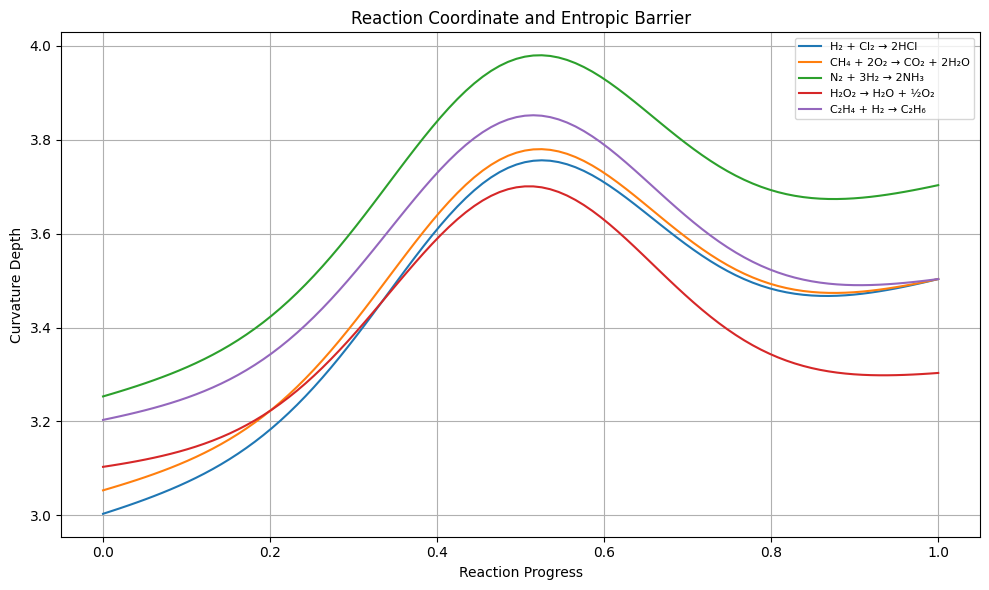

In [1]:
# Chem009: Reaction Kinetics & Activation Energy via HES curvature thresholds

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Define reactions with curvature profiles (arbitrary units)
reactions = {
    "H₂ + Cl₂ → 2HCl": {
        "reactants": [3.2, 2.8],  # H₂, Cl₂
        "products": [3.5, 3.5]    # 2HCl
    },
    "CH₄ + 2O₂ → CO₂ + 2H₂O": {
        "reactants": [3.0, 3.1],  # CH₄, O₂
        "products": [3.6, 3.4]    # CO₂, H₂O
    },
    "N₂ + 3H₂ → 2NH₃": {
        "reactants": [3.3, 3.2],  # N₂, H₂
        "products": [3.7, 3.7]    # NH₃
    },
    "H₂O₂ → H₂O + ½O₂": {
        "reactants": [3.1],       # H₂O₂
        "products": [3.4, 3.2]    # H₂O, O₂
    },
    "C₂H₄ + H₂ → C₂H₆": {
        "reactants": [3.2, 3.2],  # C₂H₄, H₂
        "products": [3.5]         # C₂H₆
    }
}

# Function to calculate activation energy and tunneling probability
def simulate_reaction(reactants, products):
    avg_reactant = np.mean(reactants)
    avg_product = np.mean(products)
    activation_energy = abs(avg_product - avg_reactant) + 0.5  # add barrier offset
    tunneling_prob = np.exp(-activation_energy)  # simplified entropic tunneling model
    curvature_change = avg_product - avg_reactant
    return round(activation_energy, 2), round(tunneling_prob, 4), round(curvature_change, 2)

# Run simulation and collect results
results = []
for reaction, profiles in reactions.items():
    Ea, P_tunnel, ΔC = simulate_reaction(profiles["reactants"], profiles["products"])
    results.append({
        "Reaction": reaction,
        "Activation Energy": Ea,
        "Tunneling Probability": P_tunnel,
        "Curvature Change": ΔC
    })

# Display results table
df = pd.DataFrame(results)
print(df)

# Visualize reaction coordinates
fig, ax = plt.subplots(figsize=(10, 6))
for i, (reaction, profiles) in enumerate(reactions.items()):
    x = np.linspace(0, 1, 100)
    reactant_c = np.mean(profiles["reactants"])
    product_c = np.mean(profiles["products"])
    barrier = max(reactant_c, product_c) + 0.5
    y = (1 - x) * reactant_c + x * product_c + np.exp(-((x - 0.5)**2) * 20) * (barrier - max(reactant_c, product_c))
    ax.plot(x, y, label=reaction)
ax.set_title("Reaction Coordinate and Entropic Barrier")
ax.set_xlabel("Reaction Progress")
ax.set_ylabel("Curvature Depth")
ax.legend(fontsize=8)
plt.grid(True)
plt.tight_layout()
plt.show()
